In [6]:
import torch
import cv2
from torchvision import transforms

In [7]:
from ref import EViT

In [8]:
model = EViT(num_classes=81)

state_dict = torch.load(r"E:/model.pth",map_location="cpu")

In [9]:
# Load trained model
model.load_state_dict(state_dict)

<All keys matched successfully>

In [11]:
model.eval()

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

EViT(
  (encoder): EViTEncoder(
    (patch_embeds): ModuleList(
      (0): OverlapPatchEmbedding(
        (proj): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
        (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      )
      (1): OverlapPatchEmbedding(
        (proj): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      )
      (2): OverlapPatchEmbedding(
        (proj): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      )
      (3): OverlapPatchEmbedding(
        (proj): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      )
    )
    (blocks): ModuleList(
      (0): ModuleList(
        (0-2): 3 x TransformerBlock(
          (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine

In [17]:
import torch

# Create random image tensor
img = torch.rand(1, 3, 512, 512)  # [batch, channels, height, width]

print(img.shape)
img = img.to(device)

torch.Size([1, 3, 512, 512])


In [18]:
with torch.no_grad():
    outputs = model(img)

print(type(outputs))
print(outputs.shape if hasattr(outputs, "shape") else outputs)

<class 'torch.Tensor'>
torch.Size([1, 81, 512, 512])


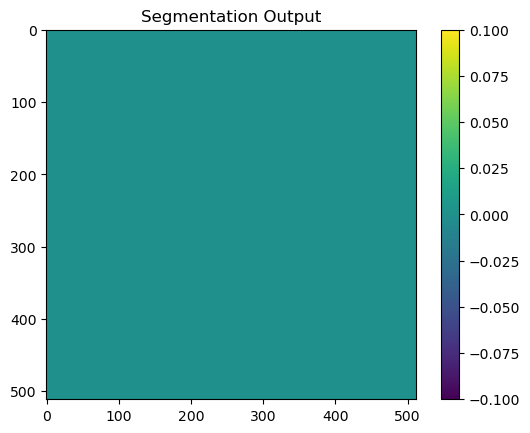

In [19]:
pred = torch.argmax(outputs, dim=1)
pred = pred.squeeze().cpu().numpy()
import matplotlib.pyplot as plt

plt.imshow(pred)
plt.colorbar()
plt.title("Segmentation Output")
plt.show()

In [12]:
# Image transform
transform = transforms.Compose([
    transforms.ToTensor()
])

# Open webcam
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # preprocess
    img = transform(frame).to(device)
    img = img.unsqueeze(0)

    with torch.no_grad():
        outputs = model(img)

    # Example for detection models (FasterRCNN style output)
    boxes = outputs[0]['boxes']
    scores = outputs[0]['scores']

    for box, score in zip(boxes, scores):
        if score > 0.5:
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(frame, (x1,y1), (x2,y2), (0,255,0), 2)

    cv2.imshow("Real-time Detection", frame)

    if cv2.waitKey(1) == 27:
        break

cap.release()
cv2.destroyAllWindows()

IndexError: too many indices for tensor of dimension 3